# **Sistem Rekomendasi Destinasi Wisata di Indonesia Menggunakan Metode Content-Based Filtering**

## Import Library

In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords

# Exploratory Data Analysis

## Data Load

In [2]:
df = pd.read_csv('dataset/tourism_with_id.csv')
print("Informasi Dataset:")
df.info()

display(df.head(7))

Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Place_Id      437 non-null    int64  
 1   Place_Name    437 non-null    str    
 2   Description   437 non-null    str    
 3   Category      437 non-null    str    
 4   City          437 non-null    str    
 5   Price         437 non-null    int64  
 6   Rating        437 non-null    float64
 7   Time_Minutes  205 non-null    float64
 8   Coordinate    437 non-null    str    
 9   Lat           437 non-null    float64
 10  Long          437 non-null    float64
 11  Unnamed: 11   0 non-null      float64
 12  Unnamed: 12   437 non-null    int64  
dtypes: float64(5), int64(3), str(5)
memory usage: 44.5 KB


,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Unnamed: 11,Unnamed: 12
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153,NaN,1
1,2,Kota Tua,"Kota tua di Jakarta, yang juga bernama Kota Tu...",Budaya,Jakarta,0,4.6,90.0,"{'lat': -6.137644799999999, 'lng': 106.8171245}",-6.137645,106.817125,NaN,2
2,3,Dunia Fantasi,Dunia Fantasi atau disebut juga Dufan adalah t...,Taman Hiburan,Jakarta,270000,4.6,360.0,"{'lat': -6.125312399999999, 'lng': 106.8335377}",-6.125312,106.833538,NaN,3
3,4,Taman Mini Indonesia Indah (TMII),Taman Mini Indonesia Indah merupakan suatu kaw...,Taman Hiburan,Jakarta,10000,4.5,NaN,"{'lat': -6.302445899999999, 'lng': 106.8951559}",-6.302446,106.895156,NaN,4
4,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman Hiburan,Jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134,NaN,5
5,6,Taman Impian Jaya Ancol,Taman Impian Jaya Ancol merupakan sebuah objek...,Taman Hiburan,Jakarta,25000,4.5,10.0,"{'lat': -6.117333200000001, 'lng': 106.8579951}",-6.117333,106.857995,NaN,6
6,7,Kebun Binatang Ragunan,Kebun Binatang Ragunan adalah sebuah kebun bin...,Cagar Alam,Jakarta,4000,4.5,NaN,"{'lat': -6.3124593, 'lng': 106.8201865}",-6.312459,106.820187,NaN,7


## Check Missing Value & Duplicate Data

In [3]:
print("Jumlah Missing Values per Kolom:")
print(df.isnull().sum().sort_values(ascending=False))

print("")

print("Jumlah baris duplikat: ")
print(df.duplicated().sum())

Jumlah Missing Values per Kolom:
Unnamed: 11     437
Time_Minutes    232
Description       0
Place_Name        0
Place_Id          0
City              0
Category          0
Rating            0
Price             0
Coordinate        0
Lat               0
Long              0
Unnamed: 12       0
dtype: int64

Jumlah baris duplikat: 
0


## Distribusi Kategori

C:\Users\asus\AppData\Local\Temp\ipykernel_3480\1490097526.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Category', data=df, order=df['Category'].value_counts().index, palette='viridis')


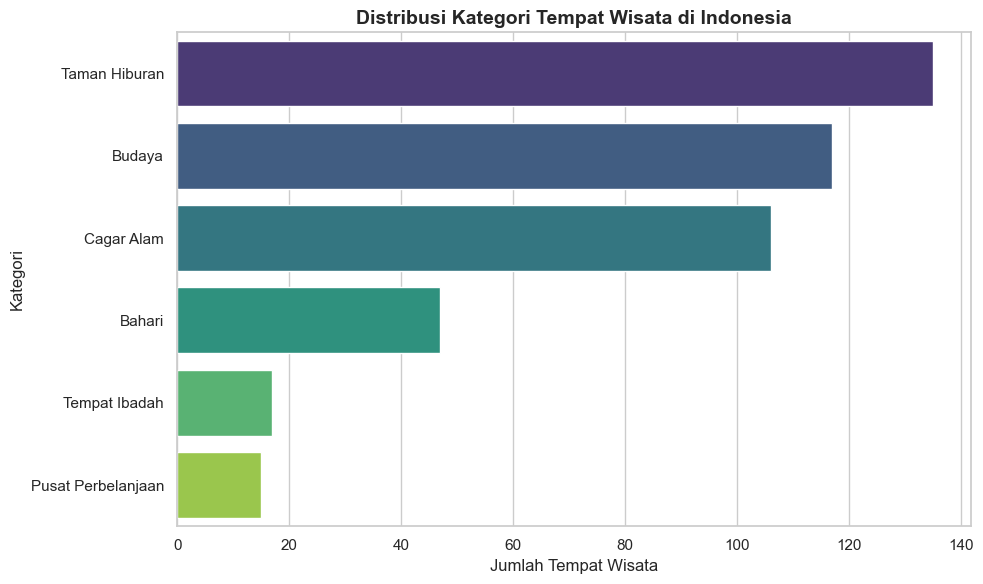

In [4]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.countplot(y='Category', data=df, order=df['Category'].value_counts().index, palette='viridis')
plt.title('Distribusi Kategori Tempat Wisata di Indonesia', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Tempat Wisata', fontsize=12)
plt.ylabel('Kategori', fontsize=12)
plt.tight_layout()
plt.show()

## Distribusi Kota

C:\Users\asus\AppData\Local\Temp\ipykernel_3480\573461461.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='City', data=df, order=df['City'].value_counts().index, palette='magma')


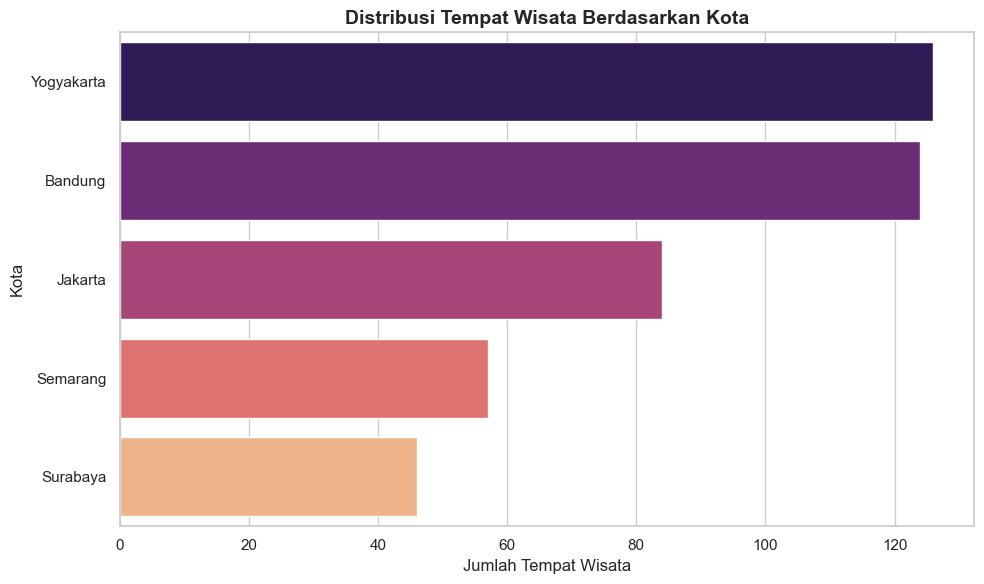

In [5]:
plt.figure(figsize=(10, 6))
sns.countplot(y='City', data=df, order=df['City'].value_counts().index, palette='magma')
plt.title('Distribusi Tempat Wisata Berdasarkan Kota', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Tempat Wisata', fontsize=12)
plt.ylabel('Kota', fontsize=12)
plt.tight_layout()
plt.show()

## Distribusi Rating dan Harga

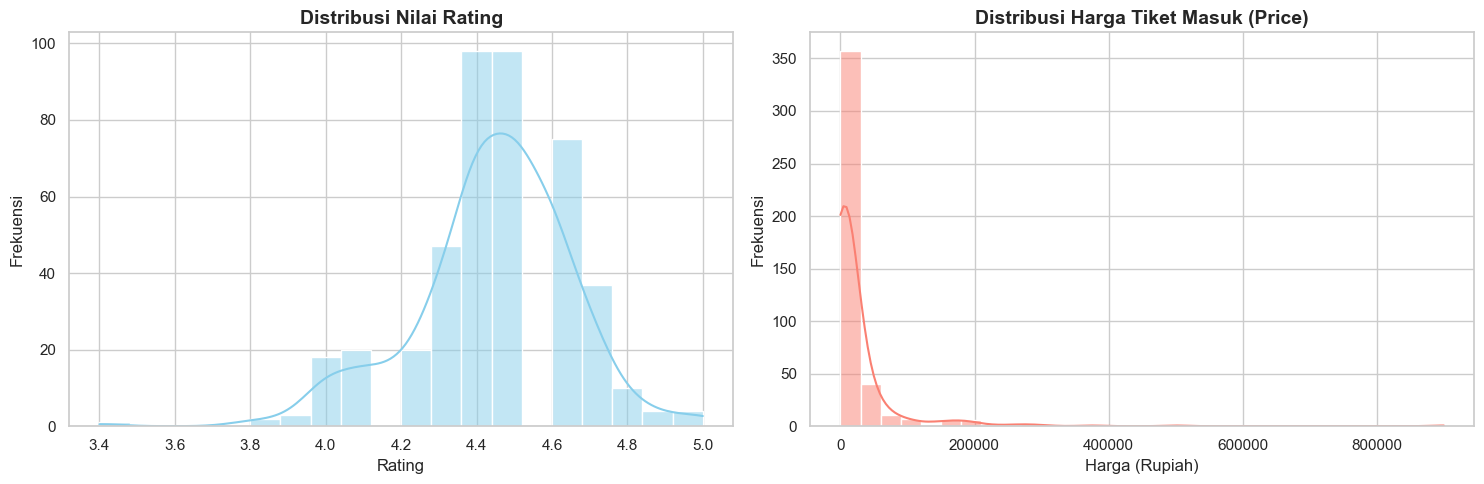

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['Rating'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Nilai Rating', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frekuensi')

sns.histplot(df['Price'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribusi Harga Tiket Masuk (Price)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Harga (Rupiah)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

## Hubungan Kategori dengan Rating

C:\Users\asus\AppData\Local\Temp\ipykernel_3480\4032572277.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Rating', y='Category', data=df, palette='Set2')


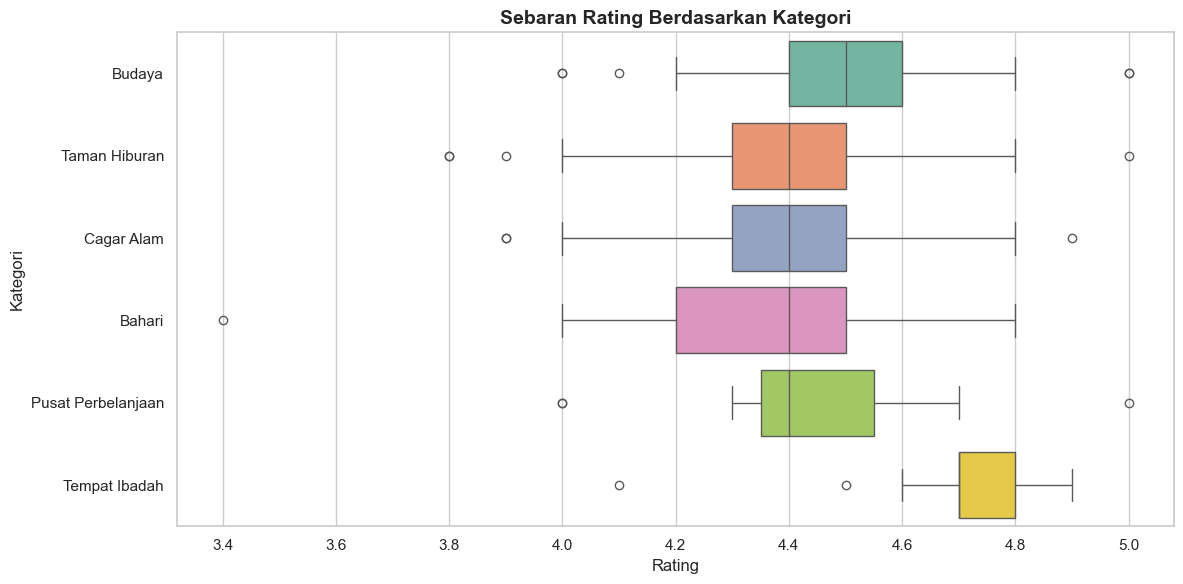

In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Rating', y='Category', data=df, palette='Set2')
plt.title('Sebaran Rating Berdasarkan Kategori', fontsize=14, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Kategori', fontsize=12)
plt.tight_layout()
plt.show()

# Data Preprocessing

## Data Cleaning & Feature Selection

In [8]:
cols_to_drop = ['Time_Minutes', 'Coordinate', 'Lat', 'Long', 'Unnamed: 11', 'Unnamed: 12']
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print("Tampilan data setelah penghapusan kolom yang tidak relevan:")
display(df_clean.head(2))

df_clean = df_clean.dropna(subset=['Place_Name', 'Description', 'Category', 'City'])

Tampilan data setelah penghapusan kolom yang tidak relevan:


,Place_Id,Place_Name,Description,Category,City,Price,Rating
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6
1,2,Kota Tua,"Kota tua di Jakarta, yang juga bernama Kota Tu...",Budaya,Jakarta,0,4.6


## Text Normalization

In [9]:
def text_cleaning(text):
    text = str(text)

    text = text.lower()
    
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    
    text = re.sub(r'\s+', ' ', text)
    
    text = text.strip()
    
    return text

df_clean['Desc_Clean'] = df_clean['Description'].apply(text_cleaning)
df_clean['Cat_Clean'] = df_clean['Category'].apply(text_cleaning)
df_clean['City_Clean'] = df_clean['City'].apply(text_cleaning)

print("Teks Sebelum Cleaning:")
print(df['Description'].iloc[0][:150] + "...")

print("\nTeks Setelah Cleaning:")
print(df_clean['Desc_Clean'].iloc[0][:150] + "...")

Teks Sebelum Cleaning:
Monumen Nasional atau yang populer disingkat dengan Monas atau Tugu Monas adalah monumen peringatan setinggi 132 meter (433 kaki) yang didirikan untuk...

Teks Setelah Cleaning:
monumen nasional atau yang populer disingkat dengan monas atau tugu monas adalah monumen peringatan setinggi 132 meter 433 kaki yang didirikan untuk m...


## Feature Merging

In [10]:
df_clean['tags'] = df_clean['Desc_Clean'] + " " + \
                   (df_clean['Cat_Clean'] + " ") * 2 + \
                   (df_clean['City_Clean'] + " ") * 2

data_preparation = df_clean[['Place_Id', 'Place_Name', 'Category', 'City', 'Rating', 'Price', 'tags']]

print("Dataset Final:")
display(data_preparation.head())

# (Opsional) Menyimpan data yang sudah bersih agar tidak perlu preprocessing ulang dari awal
# data_preparation.to_csv('tourism_cleaned.csv', index=False)

Dataset Final:


,Place_Id,Place_Name,Category,City,Rating,Price,tags
0,1,Monumen Nasional,Budaya,Jakarta,4.6,20000,monumen nasional atau yang populer disingkat d...
1,2,Kota Tua,Budaya,Jakarta,4.6,0,kota tua di jakarta yang juga bernama kota tua...
2,3,Dunia Fantasi,Taman Hiburan,Jakarta,4.6,270000,dunia fantasi atau disebut juga dufan adalah t...
3,4,Taman Mini Indonesia Indah (TMII),Taman Hiburan,Jakarta,4.5,10000,taman mini indonesia indah merupakan suatu kaw...
4,5,Atlantis Water Adventure,Taman Hiburan,Jakarta,4.5,94000,atlantis water adventure atau dikenal dengan a...


# Model

## Baseline Model

In [11]:
def get_popularity_baseline(dataframe, top_n=5):
    baseline = dataframe.sort_values(by=['Rating', 'Price'], ascending=[False, True])
    
    result = baseline[['Place_Id', 'Place_Name', 'Category', 'City', 'Rating', 'Price']].head(top_n)
    return result

print("Top 5 Destinasi Populer:")
display(get_popularity_baseline(df))

Top 5 Destinasi Populer:


,Place_Id,Place_Name,Category,City,Rating,Price
28,29,Wisata Kuliner Pecenongan,Pusat Perbelanjaan,Jakarta,5.0,0
68,69,Freedom Library,Budaya,Jakarta,5.0,0
94,95,Desa Wisata Sungai Code Jogja Kota,Taman Hiburan,Yogyakarta,5.0,0
123,124,Kauman Pakualaman Yogyakarta,Budaya,Yogyakarta,5.0,0
277,278,Masjid Daarut Tauhiid Bandung,Tempat Ibadah,Bandung,4.9,0


## Model Content Based Filtering

In [12]:
indo_stopwords = stopwords.words('indonesian')
custom_stopwords = indo_stopwords + ['wisata', 'tempat', 'berada', 'terletak', 'merupakan', 'juga', 'dengan']

tfidf = TfidfVectorizer(stop_words=custom_stopwords)

tfidf_matrix = tfidf.fit_transform(df_clean['tags'])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(f"Ukuran Matriks TF-IDF: {tfidf_matrix.shape}")
print(f"Ukuran Matriks Cosine Similarity: {cosine_sim.shape}")

Ukuran Matriks TF-IDF: (437, 6077)
Ukuran Matriks Cosine Similarity: (437, 437)


d:\SUNIB\SEM 4\Machine Learning\MLFinalProject\Recommender_System_Destination\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['baiknya', 'berkali', 'kali', 'kurangnya', 'mata', 'olah', 'sekurang', 'setidak', 'tama', 'tidaknya'] not in stop_words.
  warnings.warn(


# Recomendation Function

In [13]:
def smart_recommender(keyword=None, kota=None, kategori=None, items=df_clean, similarity_data=cosine_sim, k=5):
    
    filtered_df = items.copy()
    
    if keyword:
        idx_list = items[items['Place_Name'].str.lower() == keyword.lower()].index
        
        if len(idx_list) > 0:
            idx = idx_list[0]
            sim_scores = list(enumerate(similarity_data[idx]))
            sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:k+1]
            place_indices = [i[0] for i in sim_scores]
            
            recomends = items[['Place_Name', 'Category', 'City', 'Rating', 'Price', 'Description']].iloc[place_indices].copy()
            recomends['Similarity'] = [round(i[1], 2) for i in sim_scores]
            return recomends
        else:
            filtered_df = filtered_df[filtered_df['tags'].str.contains(keyword.lower(), na=False)]

    if kota:
        filtered_df = filtered_df[filtered_df['City'].str.lower() == kota.lower()]
    if kategori:
        filtered_df = filtered_df[filtered_df['Category'].str.lower() == kategori.lower()]

    if filtered_df.empty:
        return pd.DataFrame({"Pesan": ["Maaf, tidak ada wisata yang sesuai kriteria Anda."]})
    
    return filtered_df.sort_values(by=['Rating', 'Price'], ascending=[False, True])[['Place_Name', 'Category', 'City', 'Rating', 'Price', 'Description']].head(k)

# Evaluation Model

In [14]:
def evaluate_model(target_place, k=5):
    target_data = df_clean[df_clean['Place_Name'] == target_place]
    if target_data.empty: return None
    
    target_category = target_data['Category'].values[0]
    
    recs = smart_recommender(keyword=target_place, k=k)
    
    total_relevant_in_dataset = len(df_clean[df_clean['Category'] == target_category]) - 1
    relevance_array = [1 if cat == target_category else 0 for cat in recs['Category']]
    
    hits = sum(relevance_array)
    precision_at_k = hits / k
    recall_at_k = hits / total_relevant_in_dataset if total_relevant_in_dataset > 0 else 0
    f1 = 2 * (precision_at_k * recall_at_k) / (precision_at_k + recall_at_k) if (precision_at_k + recall_at_k) > 0 else 0
        
    ap = 0
    relevant_count = 0
    for i, is_relevant in enumerate(relevance_array):
        if is_relevant == 1:
            relevant_count += 1
            ap += relevant_count / (i + 1)
            
    ap = ap / hits if hits > 0 else 0
    return precision_at_k, recall_at_k, f1, ap

def evaluate_all_dataset(k=5):
    precisions, recalls, f1_scores, ap_scores = [], [], [], []
    
    semua_tempat = df_clean['Place_Name'].tolist()
    
    for place in semua_tempat:
        hasil = evaluate_model(place, k=k)
        if hasil is None:
            continue
            
        p, r, f1, ap = hasil
        precisions.append(p)
        recalls.append(r)
        f1_scores.append(f1)
        ap_scores.append(ap)
        
    avg_precision = np.mean(precisions)
    avg_recall = np.mean(recalls)
    avg_f1 = np.mean(f1_scores)
    map_score = np.mean(ap_scores) 
    
    print("\n" + "="*40)
    print("  HASIL EVALUASI KESELURUHAN MODEL ")
    print("="*40)
    print(f"Total Data Dievaluasi : {len(precisions)} Tempat Wisata")
    print("-" * 40)
    print(f"Mean Precision@{k}   : {avg_precision:.4f}")
    print(f"Mean Recall@{k}      : {avg_recall:.4f}")
    print(f"Mean F1-Score       : {avg_f1:.4f}")
    print(f"MAP (Mean Avg Prec) : {map_score:.4f}")
    print("="*40)

evaluate_all_dataset(k=5)


  HASIL EVALUASI KESELURUHAN MODEL 
Total Data Dievaluasi : 437 Tempat Wisata
----------------------------------------
Mean Precision@5   : 0.7670
Mean Recall@5      : 0.0555
Mean F1-Score       : 0.0976
MAP (Mean Avg Prec) : 0.8500


# Testing

In [15]:
def interactive_user_testing():
    print("="*60)
    print("  SISTEM REKOMENDASI WISATA INDONESIA ")
    print("="*60)
    print("Petunjuk: Kosongkan jawaban (langsung tekan Enter) jika tidak ingin memfilter kriteria tersebut.")
    print("Ketik 'exit' atau 'keluar' pada Nama Tempat untuk menghentikan program.\n")
    
    while True:
        print("-" * 60)
        input_nama = input("1. Masukkan Nama Tempat / Keyword : ").strip()

        if input_nama.lower() in ['exit', 'keluar']:
            break
            
        input_kota = input("2. Masukkan Kota (Jakarta | Bandung | Semarang | Yogyakarta | Surabaya): ").strip()
        input_kategori = input("3. Masukkan Kategori (Taman Hiburan | Budaya | Cagar Alam | Bahari | Tempat Ibadah | Pusat Perbelanjaan): ").strip()

        keyword_param = input_nama if input_nama != "" else None
        kota_param = input_kota if input_kota != "" else None
        kategori_param = input_kategori if input_kategori != "" else None

        hasil = smart_recommender(keyword=keyword_param, kota=kota_param, kategori=kategori_param, k=5)

        print("\n HASIL REKOMENDASI ")
        display(hasil)
        print("\n")

interactive_user_testing()

  SISTEM REKOMENDASI WISATA INDONESIA 
Petunjuk: Kosongkan jawaban (langsung tekan Enter) jika tidak ingin memfilter kriteria tersebut.
Ketik 'exit' atau 'keluar' pada Nama Tempat untuk menghentikan program.

------------------------------------------------------------


Latency (Must < 100ms)

In [ ]:
import time

start_time = time.time()

hasil = smart_recommender(keyword="Dunia Fantasi", k=5)

end_time = time.time()

latency_ms = (end_time - start_time) * 1000

print(f"Hasil Rekomendasi:")
display(hasil)
print("-" * 30)
print(f"Waktu Eksekusi (Latensi): {latency_ms:.2f} ms")

Hasil Rekomendasi:


,Place_Name,Category,City,Rating,Price,Description,Similarity
5,Taman Impian Jaya Ancol,Taman Hiburan,Jakarta,4.5,25000,Taman Impian Jaya Ancol merupakan sebuah objek...,0.61
8,Pelabuhan Marina,Bahari,Jakarta,4.4,175000,Pelabuhan Marina Ancol berada di kawasan Taman...,0.25
3,Taman Mini Indonesia Indah (TMII),Taman Hiburan,Jakarta,4.5,10000,Taman Mini Indonesia Indah merupakan suatu kaw...,0.25
46,Taman Situ Lembang,Taman Hiburan,Jakarta,4.5,0,Taman Situ Lembang adalah sebuah taman kota ya...,0.22
78,Taman Spathodea,Taman Hiburan,Jakarta,4.6,0,Objek Wisata Taman Spathodea di Jagakarsa DKI ...,0.21


------------------------------
Waktu Eksekusi (Latensi): 2.67 ms
